In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

# Save all plots into an "outputs" folder created in the current working directory
OUT = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT, exist_ok=True)
plt.rcParams["figure.dpi"] = 110

%matplotlib inline

## Task 1: Data Preparation

In [2]:
df = pd.read_csv("brca.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")])

# Clean column names (strip the "x." prefix used in this export)
df.columns = [c.replace("x.", "") if c != "y" else c for c in df.columns]

print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
print(f"Column dtypes:\n{df.dtypes.value_counts()}")

# Missing values & duplicates
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total duplicate rows : {df.duplicated().sum()}")

Column dtypes:
float64    30
str         1
Name: count, dtype: int64

Total missing values: 0
Total duplicate rows : 0


In [4]:
# Target distribution -> map to match problem statement convention
# (0 = Malignant, 1 = Benign)
df["target"] = df["y"].map({"M": 0, "B": 1})
print(f"Target distribution:\n{df['y'].value_counts()}")
print("(0 = Malignant, 1 = Benign, matching the problem statement convention)")

X = df.drop(columns=["y", "target"])
y = df["target"].values
feature_names = X.columns.tolist()

print(f"\nNumber of features: {X.shape[1]}")

Target distribution:
y
B    357
M    212
Name: count, dtype: int64
(0 = Malignant, 1 = Benign, matching the problem statement convention)

Number of features: 30


In [5]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Why StandardScaler is important here:**
- KNN is a **distance-based** algorithm (Euclidean/Manhattan). Features like `area_mean` range in the hundreds/thousands while `smoothness_mean` is a small decimal (0-1 range). Without scaling, large-magnitude features (area, perimeter) would dominate the distance calculation and small but informative features (smoothness, symmetry) would be effectively ignored.
- StandardScaler transforms every feature to mean = 0, std = 1, so all 30 features contribute proportionally to the distance metric.

## Task 2: Train-Test Split Analysis (80:20, 70:30, 90:10)

In [6]:
split_ratios = {"80:20": 0.20, "70:30": 0.30, "90:10": 0.10}
split_results = {}

for name, test_size in split_ratios.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    k_default = 5
    model = KNeighborsClassifier(n_neighbors=k_default)
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    split_results[name] = acc
    print(f"Split {name:6s} -> Train size={X_tr.shape[0]:3d}, "
          f"Test size={X_te.shape[0]:3d}, Accuracy (K=5) = {acc:.4f}")

Split 80:20  -> Train size=455, Test size=114, Accuracy (K=5) = 0.9649
Split 70:30  -> Train size=398, Test size=171, Accuracy (K=5) = 0.9708
Split 90:10  -> Train size=512, Test size= 57, Accuracy (K=5) = 0.9825


**Observation:**
- Larger training sets (90:10) generally give the model more data to learn from, but the test accuracy is estimated on very few samples, making it less stable/reliable.
- Smaller training sets (70:30) leave more data for testing (more reliable estimate) but the model itself may be very slightly under-trained.
- 80:20 is usually the best trade-off between training data volume and a test set large enough to give a stable performance estimate.

In [7]:
# Use 80:20 split going forward for the rest of the lab
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

## Task 3: KNN Model with Heuristic K Selection

### 3.1 & 3.2 — Heuristic K and nearby values (K ± 5)

In [8]:
n_train = X_train.shape[0]
k_heuristic = int(round(np.sqrt(n_train)))
if k_heuristic % 2 == 0:          # prefer odd K to avoid ties in binary classification
    k_heuristic += 1

print(f"Number of training samples (n) = {n_train}")
print(f"Heuristic K = sqrt(n) = sqrt({n_train}) ~= {k_heuristic} (rounded to nearest odd)")

k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)
    print(f"K = {k:3d} -> Test Accuracy = {acc:.4f}")

best_k_idx = int(np.argmax(accuracies))
best_k_heuristic_range = list(k_range)[best_k_idx]
print(f"\nBest K in heuristic range (K +/- 5): {best_k_heuristic_range} "
      f"(Accuracy = {accuracies[best_k_idx]:.4f})")

Number of training samples (n) = 455
Heuristic K = sqrt(n) = sqrt(455) ~= 21 (rounded to nearest odd)
K =  16 -> Test Accuracy = 0.9737
K =  17 -> Test Accuracy = 0.9737
K =  18 -> Test Accuracy = 0.9825
K =  19 -> Test Accuracy = 0.9737
K =  20 -> Test Accuracy = 0.9649
K =  21 -> Test Accuracy = 0.9561
K =  22 -> Test Accuracy = 0.9561
K =  23 -> Test Accuracy = 0.9649
K =  24 -> Test Accuracy = 0.9561
K =  25 -> Test Accuracy = 0.9649
K =  26 -> Test Accuracy = 0.9561

Best K in heuristic range (K +/- 5): 18 (Accuracy = 0.9825)


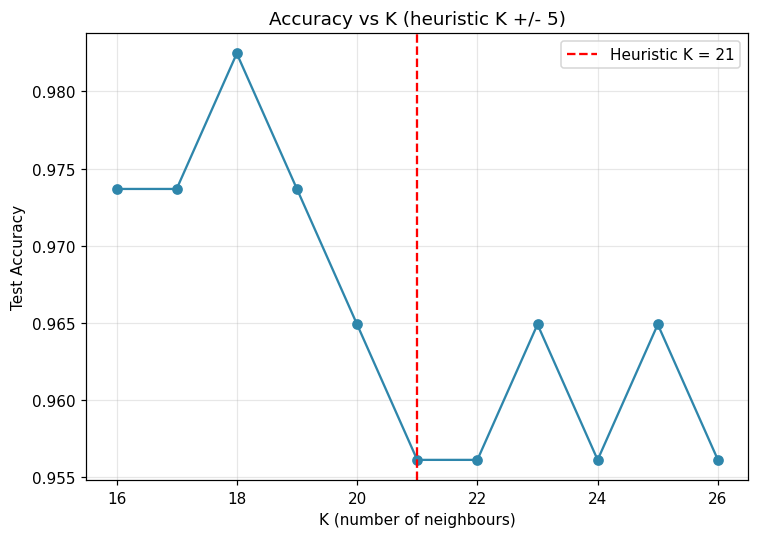

In [9]:
# Plot: Accuracy vs K
plt.figure(figsize=(7, 5))
plt.plot(list(k_range), accuracies, marker="o", color="#2E86AB")
plt.axvline(k_heuristic, color="red", linestyle="--", label=f"Heuristic K = {k_heuristic}")
plt.xlabel("K (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (heuristic K +/- 5)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "task3_accuracy_vs_k.png"))
plt.show()

### 3.3 — Distance Metrics

**1) Euclidean Distance:** d(p,q) = sqrt( Σ (p_i − q_i)² )
- Straight-line ("as the crow flies") distance between two points.
- Suitable when features are continuous and roughly on the same scale (after standardisation), and when the geometric/real distance between points is meaningful — e.g. this dataset's cell nuclei measurements (radius, area, perimeter, etc.), where overall shape similarity matters.

**2) Manhattan Distance:** d(p,q) = Σ |p_i − q_i|
- Sum of absolute differences along each axis ("grid-like" distance, like walking along city blocks).
- Suitable in high-dimensional spaces or when features represent independent, non-correlated attributes, and it is less sensitive to large outliers in a single feature than Euclidean distance (because differences aren't squared).

### 3.3 — Decision Boundary Mapping (PCA-reduced to 2D for visualisation)

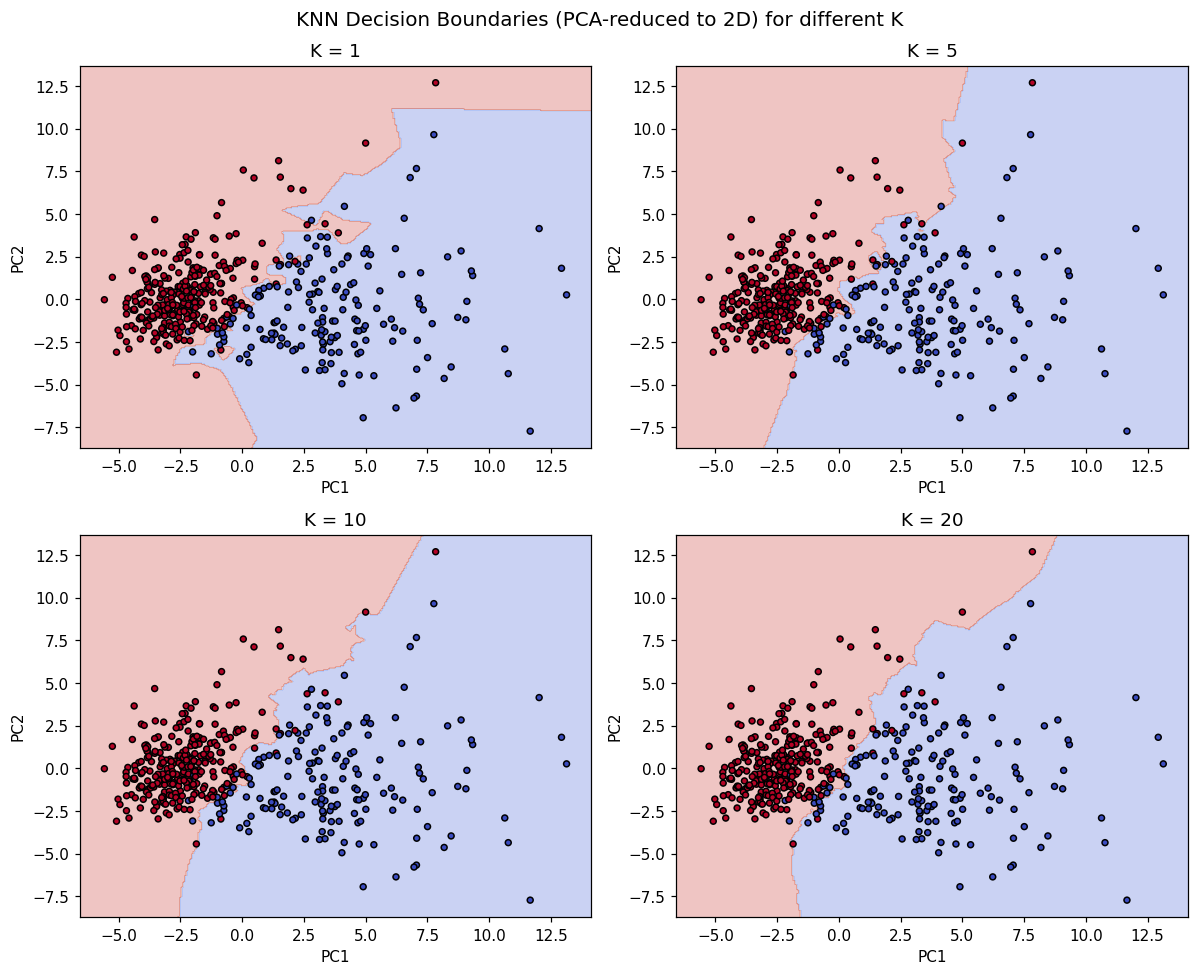

In [10]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

k_values_boundary = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300),
)

for ax, k in zip(axes.ravel(), k_values_boundary):
    clf_2d = KNeighborsClassifier(n_neighbors=k)
    clf_2d.fit(X_train_2d, y_train)
    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train,
               cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.suptitle("KNN Decision Boundaries (PCA-reduced to 2D) for different K", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "task3_decision_boundaries.png"))
plt.show()

**Decision boundary analysis as K increases:**
- **K = 1:** Very jagged, irregular boundary that tightly wraps individual training points (including noise/outliers) → low bias, high variance, prone to overfitting.
- **K = 5:** Boundary becomes noticeably smoother; small noisy pockets disappear, giving a more generalisable separation between classes.
- **K = 10:** Boundary is smoother still; the model relies on a larger local neighbourhood, reducing sensitivity to individual noisy points further.
- **K = 20:** Boundary becomes very smooth / almost linear in places; the model starts to underfit, and points near the true class border may be misclassified because too many far-away neighbours are being averaged in (high bias, low variance).

## Task 4: Cross Validation

In [11]:
cv_k_range = range(1, 31)
cv5_scores, cv10_scores = [], []

for k in cv_k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    cv5 = cross_val_score(model, X_scaled, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))
    cv10 = cross_val_score(model, X_scaled, y, cv=StratifiedKFold(10, shuffle=True, random_state=42))
    cv5_scores.append(cv5.mean())
    cv10_scores.append(cv10.mean())

best_k_cv5 = list(cv_k_range)[int(np.argmax(cv5_scores))]
best_k_cv10 = list(cv_k_range)[int(np.argmax(cv10_scores))]

print(f"Best K using 5-Fold CV : {best_k_cv5}  (mean accuracy = {max(cv5_scores):.4f})")
print(f"Best K using 10-Fold CV: {best_k_cv10}  (mean accuracy = {max(cv10_scores):.4f})")

Best K using 5-Fold CV : 4  (mean accuracy = 0.9702)
Best K using 10-Fold CV: 14  (mean accuracy = 0.9737)


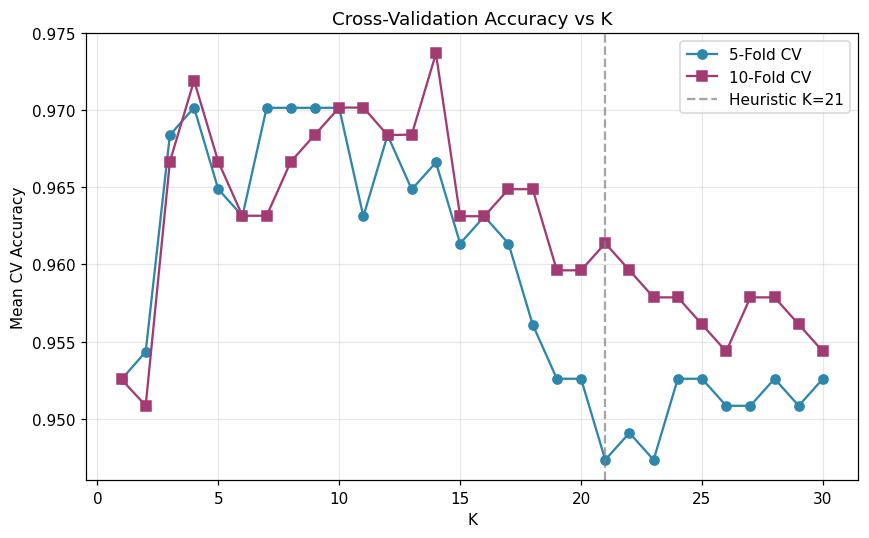

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(cv_k_range), cv5_scores, marker="o", label="5-Fold CV", color="#2E86AB")
plt.plot(list(cv_k_range), cv10_scores, marker="s", label="10-Fold CV", color="#A23B72")
plt.axvline(k_heuristic, color="gray", linestyle="--", alpha=0.7, label=f"Heuristic K={k_heuristic}")
plt.xlabel("K")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross-Validation Accuracy vs K")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "task4_cv_accuracy_vs_k.png"))
plt.show()

In [13]:
# Final K decision combining heuristic + train-test + CV evidence
final_k = best_k_cv10
print(f"""
Comparison of K selection approaches:
- Heuristic (sqrt(n))        : K = {k_heuristic}
- Best K, single 80:20 split : K = {best_k_heuristic_range}
- Best K, 5-Fold CV          : K = {best_k_cv5}
- Best K, 10-Fold CV         : K = {best_k_cv10}
""")


Comparison of K selection approaches:
- Heuristic (sqrt(n))        : K = 21
- Best K, single 80:20 split : K = 18
- Best K, 5-Fold CV          : K = 4
- Best K, 10-Fold CV         : K = 14



Cross-validation results are more reliable than a single train-test split because they average performance over multiple different data partitions, reducing the chance that the reported accuracy is an artefact of one lucky (or unlucky) split. The final K chosen for evaluation is the 10-fold CV best K, cross-checked against the heuristic value.

## Task 5: Classification Evaluation (Final Model)

In [14]:
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]   # probability of class 1 (Benign)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Final K used            : {final_k}")
print(f"Accuracy                : {acc:.4f}")
print(f"Precision               : {prec:.4f}")
print(f"Recall                  : {rec:.4f}")
print(f"F1 Score                : {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")

Final K used            : 14
Accuracy                : 0.9649
Precision               : 0.9595
Recall                  : 0.9861
F1 Score                : 0.9726
Confusion Matrix:
[[39  3]
 [ 1 71]]


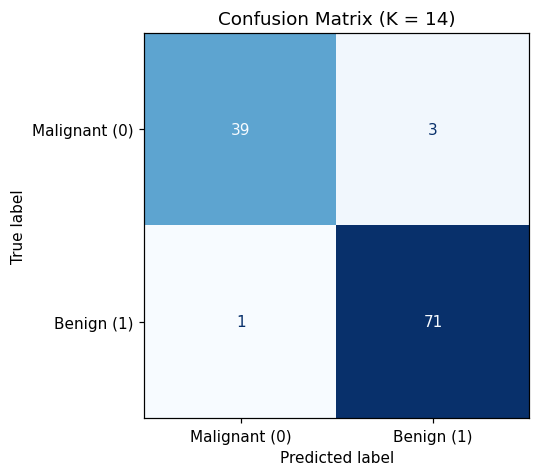

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant (0)", "Benign (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix (K = {final_k})")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "task5_confusion_matrix.png"))
plt.show()

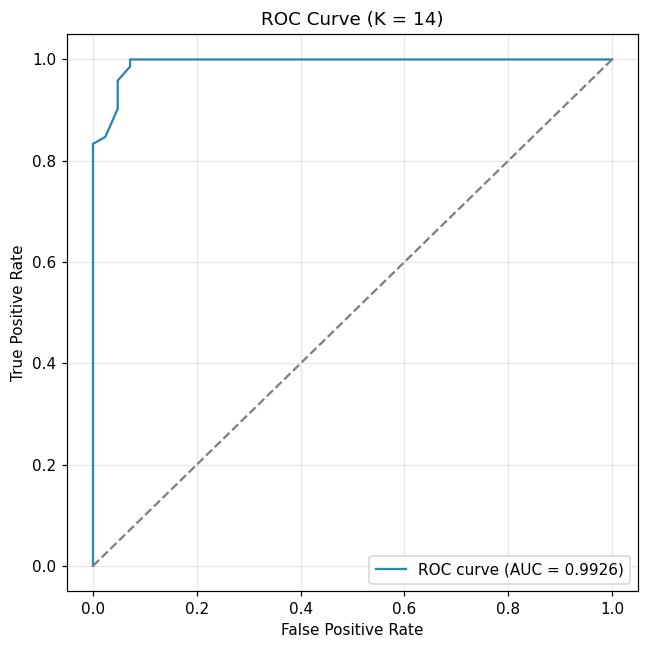

ROC-AUC Score : 0.9926


In [16]:
# ROC Curve / AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="#2E86AB", label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (K = {final_k})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "task5_roc_curve.png"))
plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

## Task 6: Comparative Study with Regression (Lab 3 Integration)

| Regression metrics (Lab 3) | Classification metrics (this lab) |
|---|---|
| MAE (Mean Absolute Error) — average magnitude of error on a **continuous** target | Accuracy — fraction of correctly classified labels |
| MSE (Mean Squared Error) — squared error, penalises large errors more | Precision — of predicted positives, how many were correct |
| RMSE (Root MSE) — error in the same unit as the target | Recall — of actual positives, how many were caught |
| R² Score — proportion of variance explained (0 to 1) | F1 Score / Confusion Matrix / ROC-AUC — decision quality & error type |

**Error-based (Regression) vs Decision-based (Classification):**
- Regression metrics quantify *how far* a numeric prediction is from the true value — the error is continuous and can be small or large in degree.
- Classification metrics quantify *whether* a discrete decision (label) is right or wrong, and further break down the *type* of error (false positive vs false negative), which a single "error magnitude" number cannot capture.

**Direct conceptual comparisons:**
- **R² Score vs Accuracy** — Both are "goodness of fit" summary numbers (0 to 1 / 0% to 100%). R² measures explained variance in a continuous outcome; Accuracy measures the fraction of correctly classified labels. Neither tells you about the distribution of errors by itself — R² hides outlier residuals, Accuracy hides class imbalance and error type.
- **RMSE vs F1 Score** — RMSE penalises large numeric errors heavily (because of squaring) and is reported in the target's own units. F1 Score balances Precision and Recall into a single number for a binary decision, useful specifically when classes are imbalanced.
- **MAE vs Confusion Matrix** — MAE is a single aggregated average error value. The Confusion Matrix, in contrast, is not a single number — it is a full breakdown (TP, TN, FP, FN) showing exactly which classes are being confused with which, giving far more diagnostic detail than MAE's single continuous average.

**Continuous prediction tasks vs Classification tasks (evaluation logic):**
- Continuous (regression) evaluation asks: *"How close is my number to the actual number?"* — errors exist on a continuous scale.
- Classification evaluation asks: *"Did I assign the correct discrete category?"*, and additionally *"What kind of mistake did I make?"* (a false negative in cancer detection is far more dangerous than a false positive), which has no direct regression analogue.

## Task 7: Analytical Questions

**1) Why is KNN called a lazy learning algorithm?**
KNN does not build/learn an explicit internal model during "training" — it simply stores (memorises) the training data. All the actual computation (distance calculation, neighbour voting) is deferred until a new/test point needs to be classified. Because "learning" is delayed to prediction time rather than done upfront, KNN is called a lazy (instance-based) learner, unlike eager learners such as Logistic Regression or Decision Trees that build a model during training.

**2) Why is feature scaling required in KNN?**
KNN classifies based on distance between points. If features are on very different scales (e.g., `area_mean` in the hundreds vs `smoothness_mean` as a small decimal), the larger-scale feature dominates the distance calculation and effectively drowns out the contribution of smaller-scale but potentially important features. Scaling (e.g., StandardScaler) puts all features on a comparable scale so each contributes fairly to the distance metric.

**3) Explain heuristic K selection using the √n rule.**
A commonly used rule-of-thumb is K = √n, where n is the number of training samples. This gives a reasonable starting point that balances sensitivity to noise (too-small K) against over-smoothing (too-large K) for a dataset of that size. It is not guaranteed to be optimal, so it is typically used as a baseline and then refined by testing nearby values (K ± 5) and by cross-validation.

**4) Why is cross-validation more reliable than a single train-test split?**
A single train-test split gives one estimate of performance that depends heavily on which particular samples ended up in the test set — an "easy" or "unlucky" split can over- or under-estimate real performance. K-Fold Cross-Validation repeats training/testing across multiple different folds and averages the results, giving a more stable and less variance-prone estimate of how the model generalises.

**5) How does K affect the bias-variance trade-off?**
- Small K (e.g., K=1): low bias, high variance — the model fits very closely to individual training points/noise, so it can overfit.
- Large K: high bias, low variance — the decision becomes an average over many neighbours, smoothing out detail, which can underfit.
An optimal K balances both, minimising overall test error.

**6) Why is recall more important than accuracy in cancer prediction?**
In medical diagnosis, missing a true malignant case (a false negative) can be life-threatening, whereas a false positive typically just leads to an extra confirmatory test. Accuracy alone can look high even while the model quietly misses malignant cases (especially if classes are imbalanced). Recall specifically measures how many actual malignant cases were correctly caught, making it far more clinically relevant than overall accuracy.

**7) What is the limitation of very large K values?**
As K grows very large, the neighbourhood used for prediction includes points that are increasingly far away and less relevant, causing the decision boundary to become overly smooth and biased toward the majority class. This can cause the model to underfit and lose the ability to correctly classify samples near the true class boundary; in the extreme case (K = n), every point would simply be classified as the majority class in the entire training set.

## Inference

In [17]:
print(f"""
Final Model Summary (K = {final_k}):
  Accuracy  = {acc:.4f}
  Precision = {prec:.4f}
  Recall    = {rec:.4f}
  F1 Score  = {f1:.4f}
  ROC-AUC   = {roc_auc:.4f}
""")


Final Model Summary (K = 14):
  Accuracy  = 0.9649
  Precision = 0.9595
  Recall    = 0.9861
  F1 Score  = 0.9726
  ROC-AUC   = 0.9926



- Regression metrics (MAE, MSE, RMSE, R² from Lab 3) measure the **magnitude of numeric prediction error** on a continuous target — how far off, on average, predictions are from actual values.
- Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC, here) measure **decision correctness** on discrete class labels, and additionally distinguish the type of error made (false positive vs false negative).
- Accuracy alone is insufficient in medical diagnosis because the Breast Cancer dataset (and medical data generally) can be imbalanced, and, critically, all errors are not equally costly: a false negative (missed cancer) is far more dangerous than a false positive. A model can score high accuracy while still missing a meaningful fraction of malignant cases.
- Recall and ROC-AUC are more clinically relevant: Recall (Sensitivity) directly reports how many true malignant cases were correctly caught, and ROC-AUC summarises the model's ability to separate the two classes across all decision thresholds, not just one fixed cut-off.
- **Overall:** regression evaluation is about **error magnitude** on a continuous scale, while classification evaluation is about **decision quality and error type** on discrete categories — both frameworks benefit from being reported together with complementary metrics (e.g., RMSE alongside R²; Recall alongside Accuracy).

### Conclusion
- Optimal K was determined via the √n heuristic, refined across a train-test split, and confirmed with 5-fold and 10-fold cross-validation.
- Train-test split ratio affects the stability of the accuracy estimate: smaller test sets (90:10) give less stable estimates than 80:20 despite a higher raw score.
- The final KNN model performs strongly on this dataset across all classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC), with Recall and ROC-AUC being the most clinically meaningful given the medical-diagnosis context.
- Regression (Lab 3) and Classification (this lab) evaluation frameworks are conceptually parallel (both need more than one summary number) but fundamentally different in what they measure: continuous error magnitude vs discrete decision correctness.